# getting_contours_saved_in_spatialite.ipynb

I used this notebook to learn how to use contours saved as WKB blobs in SpatiaLite.

Here the steps I want to accomplish:

1. Open a test database containing images and tree contours extracted using the SAM3 segmentation model.
2. Visually check that the that the tree contour fits the tree image
3. Convert the tree contour into a tree mask.
4. Use elliptic Fourier coordinates to create a reconstruction contour.
5. Convert reconstructed contour into a reconstruction mask.
6. Calculate a difference mask containing pixels which are in the reconstruction mask but not in the original mask
7. Convert the difference mask into contours.
8. Save the difference contours as in the damage table.

In [1]:
import sqlite3
from icecream import ic
from shapely import wkb, to_wkt
from shapely.geometry import Polygon

import numpy as np
import cv2
import matplotlib.pyplot as plt
import efd_find_cuts as efd


# 1 Open a test database

In [2]:
db_path = 'test.db'
image_id = 1
tree_id = 1
order = 20

In [3]:
conn = sqlite3.connect(db_path)   
conn.enable_load_extension(True)
conn.load_extension('mod_spatialite')
cursor = conn.cursor()

# 2. Visually check that the that the tree contour fits the tree image

## Get the contour of the first tree

This is the contour calculated by SAM3 which is saved as a blob in the `tree_poly` field of the `v_tree_poly` view.

In [4]:
cursor.execute('SELECT * FROM v_tree_poly')
cursor.execute(f"SELECT image_width, image_height, AsBinary(tree_poly) AS tree_poly_binary FROM v_tree_poly WHERE tree_id = {tree_id}")
image_width, image_height, tree_poly_binary = cursor.fetchone()

# Use Shapely to convert the WKB binary to a polygon and extract the contour coordinates
tree_poly_str = wkb.loads(tree_poly_binary)
tree_contour = np.array(tree_poly_str.exterior.coords).astype(np.int32)
tree_contour = np.abs(tree_contour) # Ensure all coordinates are positive
# ic(tree_contour)
# ic(tree_contour.dtype)

# Visualize the tree contour.

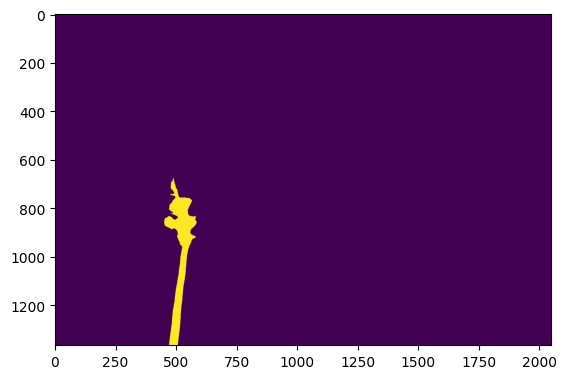

In [5]:
tree_mask = np.zeros((image_width, image_height, 1), dtype=np.uint8)
cv2.fillPoly(tree_mask, [tree_contour], 255)
plt.imshow(tree_mask);

# Make sure the contour surrounds the detected tree

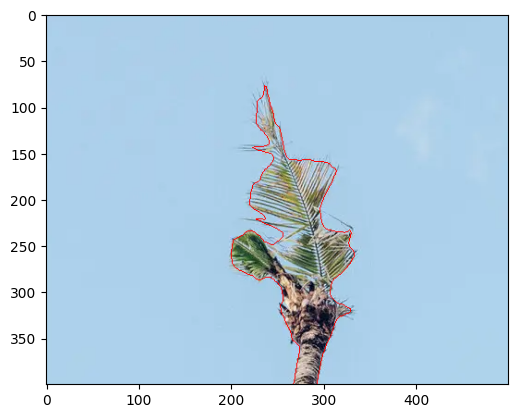

In [6]:
cursor.execute('SELECT tree_id, image_path FROM images, trees WHERE images.image_id=trees.image_id AND tree_id=1')
_, image_path = cursor.fetchone()
img = cv2.imread(image_path)
cv2.polylines(img, [tree_contour], color=(0,0,255), isClosed=True, thickness=1)
img=cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img[600:1000, 250:750]);

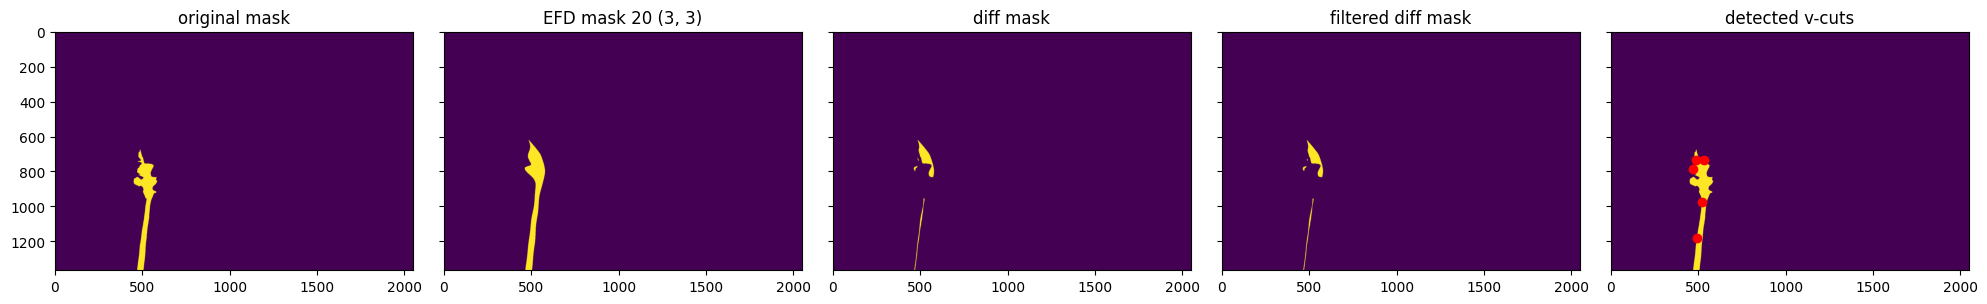

In [7]:
results = efd.efd_find_cuts(
    original_contour=tree_contour, 
    original_mask=tree_mask,
    order=order
    )
my_fig, my_axs = efd.plot_efd_results(results)
plt.show()

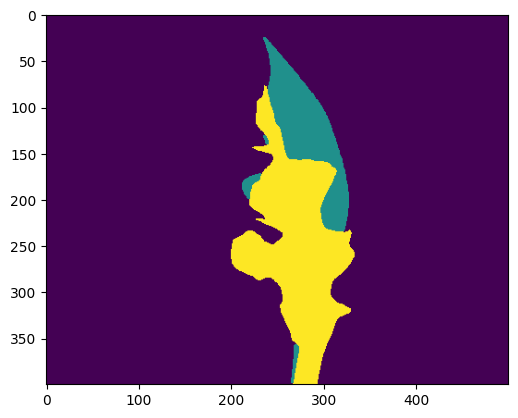

In [8]:
img = results.original_mask
cv2.fillPoly(img, results.vcut_contours, 128)
plt.imshow(img[600:1000, 250:750]);


In [9]:
for contour in results.vcut_contours:
    # convert countour to WKT format using Shapely
    squeeze_contour = np.squeeze(contour)  # Shape becomes (N, 2)
    poly = Polygon(squeeze_contour)
    wkt_string = to_wkt(poly)
    
    conn.execute(
        'INSERT INTO damage (image_id, tree_id, damage_poly) VALUES (?, ?, GeomFromText(?, 0))', 
        (image_id, tree_id, wkt_string)
    )
    
conn.commit()

# Visually check alignment of efd reconstructed poly and tree-poly

|color|var|
|--|--|
|white:|tree_contour|
|red:|aligned_recon|
|green:|raw_recon|

# !! Something weird here: "aligned_recon is misaligned" !!

# 3. EFD reconstruction

ic| original_contour.astype(np.int32): array([[486, 677],
                                              [486, 682],
                                              [485, 683],
                                              ...,
                                              [488, 678],
                                              [487, 678],
                                              [486, 677]], shape=(1084, 2), dtype=int32)


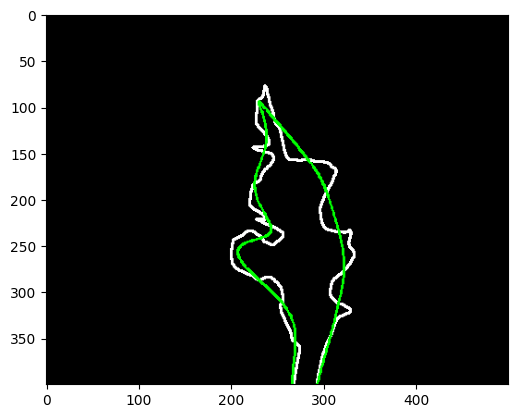

In [10]:
from pyefd import elliptic_fourier_descriptors, calculate_dc_coefficients, reconstruct_contour

original_contour=tree_contour
num_harmonics=order

original_contour = np.array(original_contour, dtype=np.float64).reshape(-1, 2)

# 1. Extract descriptors (keep normalize=False to retain native spatial details)
coeffs = elliptic_fourier_descriptors(original_contour, order=num_harmonics, normalize=False)

# 2. Extract DC spatial tracking offsets
dc_coeffs = calculate_dc_coefficients(original_contour)

# 3. Generate raw reconstruction (matching original row length for point parity)
reconstructed_contour = reconstruct_contour(
    coeffs, 
    locus=dc_coeffs, 
    num_points=len(original_contour)
)

ic(original_contour.astype(np.int32));

img = np.zeros((image_width, image_height, 3), dtype=np.uint8)
cv2.polylines(img, pts=[original_contour.astype(np.int32)], isClosed=True, color=(255, 255, 255), thickness=2)
cv2.polylines(img, pts=[reconstructed_contour.astype(np.int32)], isClosed=True, color=(0,255,0), thickness=2)
plt.imshow(img[600:1000, 250:750]);

# Now calculate mask containing pixels which are in the reconstruction mask but not in the original mask

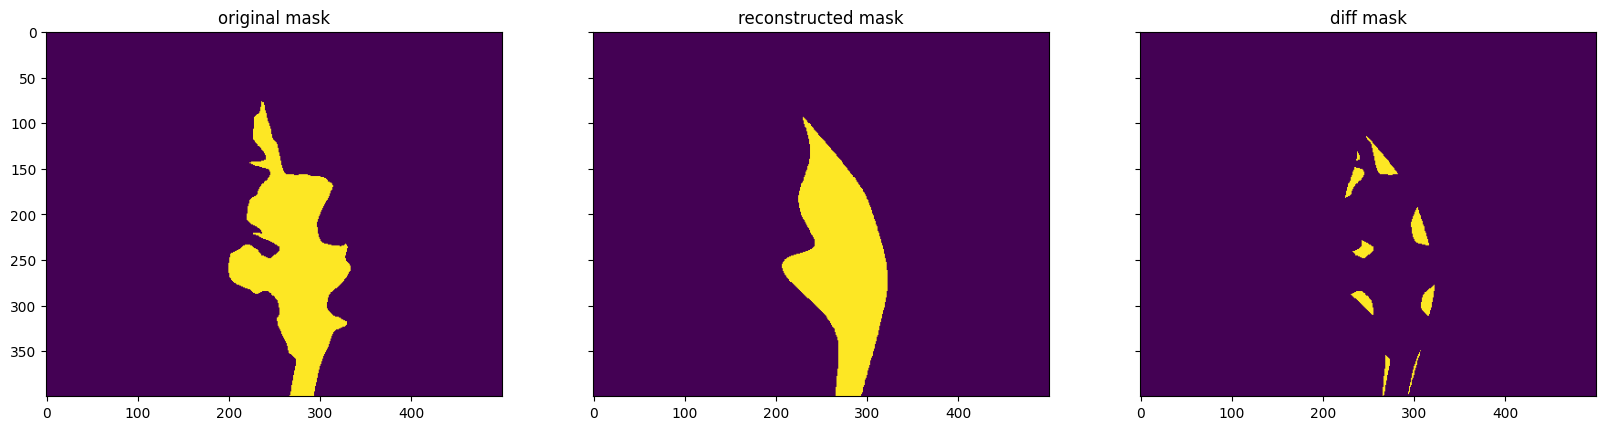

In [11]:
original_mask = np.zeros((image_width, image_height), dtype=np.uint8)
reconstructed_mask = np.zeros((image_width, image_height), dtype=np.uint8)

cv2.fillPoly(original_mask, pts=[original_contour.astype(np.int32)], color=255)
cv2.fillPoly(reconstructed_mask, pts=[reconstructed_contour.astype(np.int32)], color=255)

# Pixels missing in original, present in reconstruction
diff_mask = cv2.bitwise_and(reconstructed_mask, cv2.bitwise_not(original_mask))

fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)
axs[0].imshow(original_mask[600:1000, 250:750])
axs[0].set_title('original mask')
axs[1].imshow(reconstructed_mask[600:1000, 250:750])
axs[1].set_title('reconstructed mask')
axs[2].imshow(diff_mask[600:1000, 250:750])
axs[2].set_title('diff mask')
plt.show()


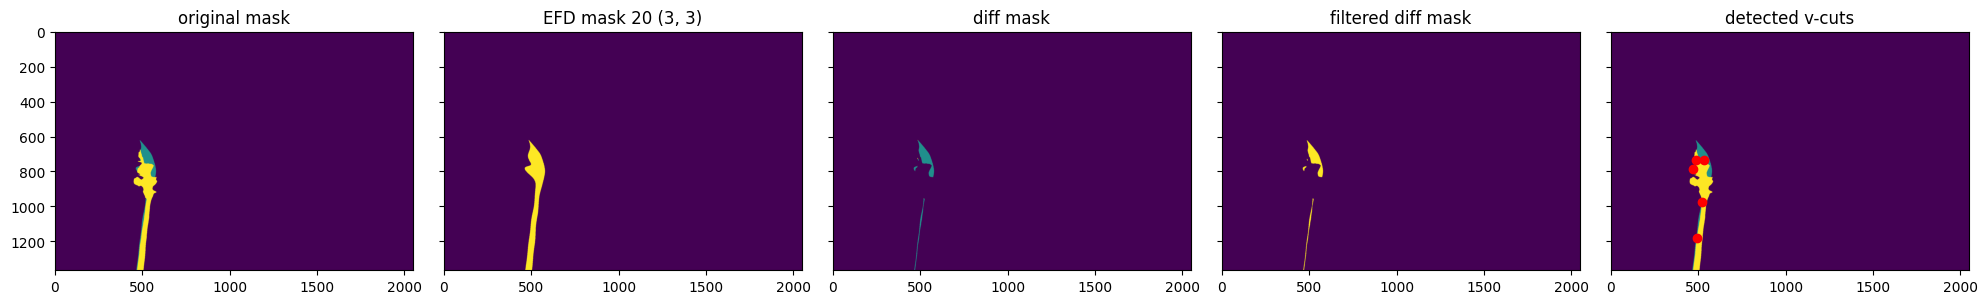

In [12]:
efd_results = efd.efd_find_cuts(
    original_contour=tree_contour,
    original_mask=tree_mask,
    order=order)
efd.plot_efd_results(efd_results);

In [13]:
conn.close()